# Notebook 02. Generación de variables (feature engineering)

A partir de los datos descargados por el notebook 01, este notebook construye la tabla maestra de variables predictoras por celda de la grilla. Para los rasters (Sentinel-1/2, GHS-BUILT, VIIRS, DEM, WorldPop) se hace muestreo en el centroide de cada celda. Para los datos vectoriales de OSM (vías y edificios) se calculan métricas espaciales explícitas: densidad de vías, distancia a vías principales, número y geometría de edificios. La salida es un GeoPackage con una fila por celda y veinticinco columnas de features, listo para entrar al modelo.


## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.config import DATA_RAW, DATA_PROC, CRS_TRABAJO
from src.features import (
    calcular_ndvi, calcular_ndbi, calcular_ndwi, calcular_bsi,
    densidad_vias_por_celda, metricas_edificios_por_celda,
    distancia_a_vias_principales, zonal_stats_multibanda,
    pendiente_desde_dem,
)

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

## 1. Cargar grilla base

In [2]:
grilla = gpd.read_file(DATA_PROC / "grilla_100m.gpkg")
print(f"Grilla cargada: {len(grilla):,} celdas en {grilla.crs}")
grilla.head(3)

Grilla cargada: 9,004 celdas en EPSG:32618


,cell_id,geometry
0,0,"POLYGON ((438098.271 1149297.722, 438098.271 1..."
1,1,"POLYGON ((438198.271 1149297.722, 438198.271 1..."
2,2,"POLYGON ((438198.271 1149397.722, 438198.271 1..."


## 2. Variables espectrales desde Sentinel-2

Se sample en el centroide de cada celda las reflectancias de Sentinel-2 en las bandas B2 (azul), B3 (verde), B4 (rojo), B5–B7 (red-edge), B8 (NIR), B8A (NIR estrecho), B11 (SWIR1) y B12 (SWIR2). A partir de ellas se derivan cuatro índices interpretables: NDVI captura cobertura vegetal, NDBI captura intensidad de construcción, NDWI captura presencia de agua, y BSI captura suelo desnudo. Estos cuatro índices son la base espectral del modelo.


In [3]:
S2_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
grilla = zonal_stats_multibanda(grilla, DATA_RAW / "sentinel2_median_2024.tif", S2_BANDS)
grilla.head(3)

,cell_id,geometry,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12
0,0,"POLYGON ((438098.271 1149297.722, 438098.271 1...",0.08480,0.09780,0.08740,0.10250,0.10100,0.11180,0.11250,0.10590,0.05750,0.03950
1,1,"POLYGON ((438198.271 1149297.722, 438198.271 1...",0.08135,0.09280,0.08890,0.09975,0.08315,0.08605,0.07040,0.08095,0.08075,0.06260
2,2,"POLYGON ((438198.271 1149397.722, 438198.271 1...",0.08705,0.09695,0.07935,0.07345,0.05545,0.05705,0.05135,0.05580,0.04360,0.03435


In [4]:
# Calcular índices
grilla["NDVI"] = calcular_ndvi(grilla["B8"], grilla["B4"])
grilla["NDBI"] = calcular_ndbi(grilla["B11"], grilla["B8"])
grilla["NDWI"] = calcular_ndwi(grilla["B3"], grilla["B8"])
grilla["BSI"] = calcular_bsi(grilla["B11"], grilla["B4"], grilla["B8"], grilla["B2"])

# Resumen
print("Estadísticas de índices espectrales:")
print(grilla[["NDVI", "NDBI", "NDWI", "BSI"]].describe().round(3))

Estadísticas de índices espectrales:
           NDVI      NDBI      NDWI       BSI
count  9004.000  9004.000  9004.000  9004.000
mean      0.270     0.066    -0.287     0.081
std       0.220     0.129     0.213     0.106
min      -0.407    -0.602    -0.792    -0.537
25%       0.122     0.007    -0.439     0.041
50%       0.230     0.088    -0.270     0.107
75%       0.417     0.154    -0.171     0.150
max       0.880     0.490     0.563     0.395


## 3. Variables SAR desde Sentinel-1

Backscatter en polarizaciones VV (vertical-vertical) y VH (vertical-horizontal), más la diferencia VH menos VV en dB como métrica de heterogeneidad superficial. La diferencia en dB es la forma estándar en SAR de expresar el ratio polarimétrico cuando las imágenes vienen en escala logarítmica, y es numéricamente más estable que el cociente directo.


In [5]:
grilla = zonal_stats_multibanda(grilla, DATA_RAW / "sentinel1_median_2024.tif", ["VV", "VH"])
# VV y VH vienen en dB. La métrica estándar de "ratio" en SAR para imágenes en dB
# es la DIFERENCIA (VH - VV), que en escala lineal equivale al ratio VH/VV.
# Más robusta numéricamente que dividir cuando VV se acerca a cero.
grilla["VH_VV_diff_db"] = grilla["VH"] - grilla["VV"]
print("Estadísticas SAR:")
print(grilla[["VV", "VH", "VH_VV_diff_db"]].describe().round(3))

Estadísticas SAR:
             VV        VH  VH_VV_diff_db
count  9004.000  9004.000       9004.000
mean     -6.436   -14.254         -7.817
std       4.948     3.743          3.473
min     -21.014   -31.203        -27.881
25%      -9.046   -15.445         -8.852
50%      -7.177   -13.973         -6.730
75%      -4.485   -12.549         -5.673
max      17.041     8.590          3.313


## 4. Superficie construida (GHS-BUILT)

In [6]:
grilla = zonal_stats_multibanda(grilla, DATA_RAW / "ghs_built_s_2020.tif", ["ghs_built"])
print(f"Celdas con superficie construida > 0: {(grilla['ghs_built'] > 0).sum():,}")

Celdas con superficie construida > 0: 7,774


## 5. Luces nocturnas (VIIRS)

In [7]:
grilla = zonal_stats_multibanda(grilla, DATA_RAW / "viirs_2024.tif", ["viirs_radiance"])
print(f"Mediana radiancia VIIRS: {grilla['viirs_radiance'].median():.3f}")

Mediana radiancia VIIRS: 64.288


## 6. Topografía (DEM + pendiente derivada)

In [8]:
grilla = zonal_stats_multibanda(grilla, DATA_RAW / "dem_glo30.tif", ["elevacion"])

# Calcular pendiente desde el raster completo y luego muestrear
with rasterio.open(DATA_RAW / "dem_glo30.tif") as src:
    dem_array = src.read(1).astype("float32")
    transform = src.transform
    crs_dem = src.crs

    # Aproximación: pixel size en metros (DEM está en geográficas → conversión aproximada)
    pixel_size_m = 30.0  # GLO30 es 30 m

    slope = pendiente_desde_dem(dem_array, cellsize=pixel_size_m)

    # Guardar pendiente como nuevo raster para muestrear con la grilla
    slope_path = DATA_PROC / "pendiente_grados.tif"
    with rasterio.open(
        slope_path, "w",
        driver="GTiff",
        height=slope.shape[0], width=slope.shape[1],
        count=1, dtype="float32",
        crs=crs_dem, transform=transform,
    ) as dst:
        dst.write(slope, 1)

grilla = zonal_stats_multibanda(grilla, slope_path, ["pendiente_grados"])
print(f"Pendiente media: {grilla['pendiente_grados'].mean():.2f}°")
print(f"Pendiente máxima: {grilla['pendiente_grados'].max():.2f}°")

Pendiente media: 2.83°
Pendiente máxima: 37.12°


## 7. Población (WorldPop)

In [9]:
grilla = zonal_stats_multibanda(grilla, DATA_RAW / "worldpop_2020.tif", ["poblacion"])
grilla["poblacion"] = grilla["poblacion"].fillna(0)
print(f"Población total estimada en la grilla: {grilla['poblacion'].sum():,.0f}")

Población total estimada en la grilla: 719,552


## 8. Métricas OSM — vías

In [10]:
vias = gpd.read_file(DATA_RAW / "osm_vias.gpkg").to_crs(CRS_TRABAJO)
print(f"Vías cargadas: {len(vias):,} segmentos")

grilla = densidad_vias_por_celda(grilla, vias)
grilla = distancia_a_vias_principales(grilla, vias)

print(f"Celdas con al menos un segmento de vía: {(grilla['vias_long_m'] > 0).sum():,}")
print(f"Distancia mediana a vía principal: {grilla['dist_via_principal_m'].median():.1f} m")

Vías cargadas: 62,173 segmentos
Celdas con al menos un segmento de vía: 7,235
Distancia mediana a vía principal: 513.2 m


## 9. Métricas de edificios desde OpenStreetMap

Por celda se calcula el número de edificios mapeados, el área total construida, el área media y la desviación del área de los edificios, y la compacidad media (definida como 4·pi·área dividido por perímetro al cuadrado, un indicador de regularidad geométrica). La cobertura de mapeo de OSM no es uniforme: barrios formales y zonas turísticas tienden a estar mejor mapeados que asentamientos informales. La ausencia de edificios mapeados no equivale a ausencia de construcciones, sino que en sí misma es una señal débil de informalidad. Este sesgo está documentado explícitamente en la nota técnica.


In [11]:
edificios = gpd.read_file(DATA_RAW / "osm_edificios.gpkg").to_crs(CRS_TRABAJO)
print(f"Edificios cargados: {len(edificios):,} polígonos")

grilla = metricas_edificios_por_celda(grilla, edificios)
print(f"Celdas con al menos 1 edificio OSM: {(grilla['n_edificios'] > 0).sum():,}")

Edificios cargados: 39,442 polígonos
Celdas con al menos 1 edificio OSM: 3,056


## 10. Limpieza y diagnóstico

In [12]:
# Eliminar celdas que están claramente fuera del área urbana
# Criterio: GHS-BUILT > 1 m² o presencia de población o algún edificio OSM
mask_urbano = (
    (grilla["ghs_built"] > 1)
    | (grilla["poblacion"] > 0)
    | (grilla["n_edificios"] > 0)
)
n_antes = len(grilla)
grilla = grilla[mask_urbano].reset_index(drop=True)
print(f"Celdas urbanas: {len(grilla):,} (descartadas {n_antes - len(grilla):,} no urbanas)")

Celdas urbanas: 8,902 (descartadas 102 no urbanas)


In [13]:
# Diagnóstico de columnas
print("\nColumnas finales en la tabla maestra:")
for c in grilla.columns:
    if c != "geometry":
        n_na = grilla[c].isna().sum()
        print(f"  {c:<30}  NaN: {n_na:>6,}/{len(grilla):,}")


Columnas finales en la tabla maestra:
  cell_id                         NaN:      0/8,902
  B2                              NaN:      0/8,902
  B3                              NaN:      0/8,902
  B4                              NaN:      0/8,902
  B5                              NaN:      0/8,902
  B6                              NaN:      0/8,902
  B7                              NaN:      0/8,902
  B8                              NaN:      0/8,902
  B8A                             NaN:      0/8,902
  B11                             NaN:      0/8,902
  B12                             NaN:      0/8,902
  NDVI                            NaN:      0/8,902
  NDBI                            NaN:      0/8,902
  NDWI                            NaN:      0/8,902
  BSI                             NaN:      0/8,902
  VV                              NaN:      0/8,902
  VH                              NaN:      0/8,902
  VH_VV_diff_db                   NaN:      0/8,902
  ghs_built              

## 11. Sello de etiquetas sobre la grilla

Los polígonos de barrios informales y formales generados en el notebook 01 (provenientes del shapefile CCV) se intersectan con los centroides de la grilla. Cada celda recibe una etiqueta binaria: 1 si su centroide cae dentro de un barrio informal, 0 si cae dentro de un barrio formal, y NaN si no cae en ninguno de los dos (esa parte de la grilla queda como conjunto de inferencia para que el modelo prediga).


In [14]:
positivos = gpd.read_file(DATA_RAW / "etiquetas_positivas_zona_norte.gpkg").to_crs(CRS_TRABAJO)
negativos = gpd.read_file(DATA_RAW / "etiquetas_negativas_barrios_formales.gpkg").to_crs(CRS_TRABAJO)

grilla["centroide"] = grilla.geometry.centroid
cents = gpd.GeoDataFrame(grilla[["cell_id"]], geometry=grilla["centroide"], crs=grilla.crs)

# sjoin puede devolver múltiples filas por celda si su centroide cae en varios polígonos
# (ej. polígonos CCV con nombres repetidos). Se deduplica por cell_id.
pos_match = gpd.sjoin(cents, positivos[["geometry"]], how="inner", predicate="within")
celdas_pos = set(pos_match["cell_id"].unique())
grilla["es_positivo"] = grilla["cell_id"].isin(celdas_pos)

neg_match = gpd.sjoin(cents, negativos[["geometry"]], how="inner", predicate="within")
celdas_neg = set(neg_match["cell_id"].unique())
grilla["es_negativo"] = grilla["cell_id"].isin(celdas_neg)

# Etiqueta final (0=formal, 1=informal, NaN=sin etiqueta)
grilla["etiqueta"] = np.nan
grilla.loc[grilla["es_positivo"], "etiqueta"] = 1
grilla.loc[grilla["es_negativo"], "etiqueta"] = 0

print(f"Resumen de etiquetas:")
print(f"Positivos (informales CCV): {(grilla['etiqueta'] == 1).sum():,}")
print(f"Negativos (formales CCV):   {(grilla['etiqueta'] == 0).sum():,}")
print(f"Sin etiqueta (inferencia):  {grilla['etiqueta'].isna().sum():,}")

grilla = grilla.drop(columns=["centroide"])

Resumen de etiquetas:
Positivos (informales CCV): 1,095
Negativos (formales CCV):   1,686
Sin etiqueta (inferencia):  6,121


## 12. Guardado de la tabla maestra

In [15]:
out_path = DATA_PROC / "tabla_maestra_features.gpkg"
grilla.to_file(out_path, driver="GPKG")
print(f"(ok) Tabla maestra (GeoPackage): {out_path}")

# Exportar también CSV (sin geometría, con centroide x/y) — útil para Excel/R/inspección rápida
csv_out = DATA_PROC / "tabla_maestra_features.csv"
df_csv = grilla.drop(columns="geometry").copy()
df_csv["centroid_x_utm"] = grilla.geometry.centroid.x
df_csv["centroid_y_utm"] = grilla.geometry.centroid.y
df_csv.to_csv(csv_out, index=False, encoding="utf-8")
print(f"(ok) Tabla maestra (CSV plano): {csv_out}")
print(f"  Filas: {len(grilla):,}  ·  Columnas: {grilla.shape[1]}")

(ok) Tabla maestra (GeoPackage): /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/processed/tabla_maestra_features.gpkg
(ok) Tabla maestra (CSV plano): /Users/transformaciondigita/PERSONALES/onu-habitat/entrevista-onu-habitat/prueba-tecnica-cartagena/data/processed/tabla_maestra_features.csv
  Filas: 8,902  ·  Columnas: 34


## 13. Visualización rápida de algunas variables

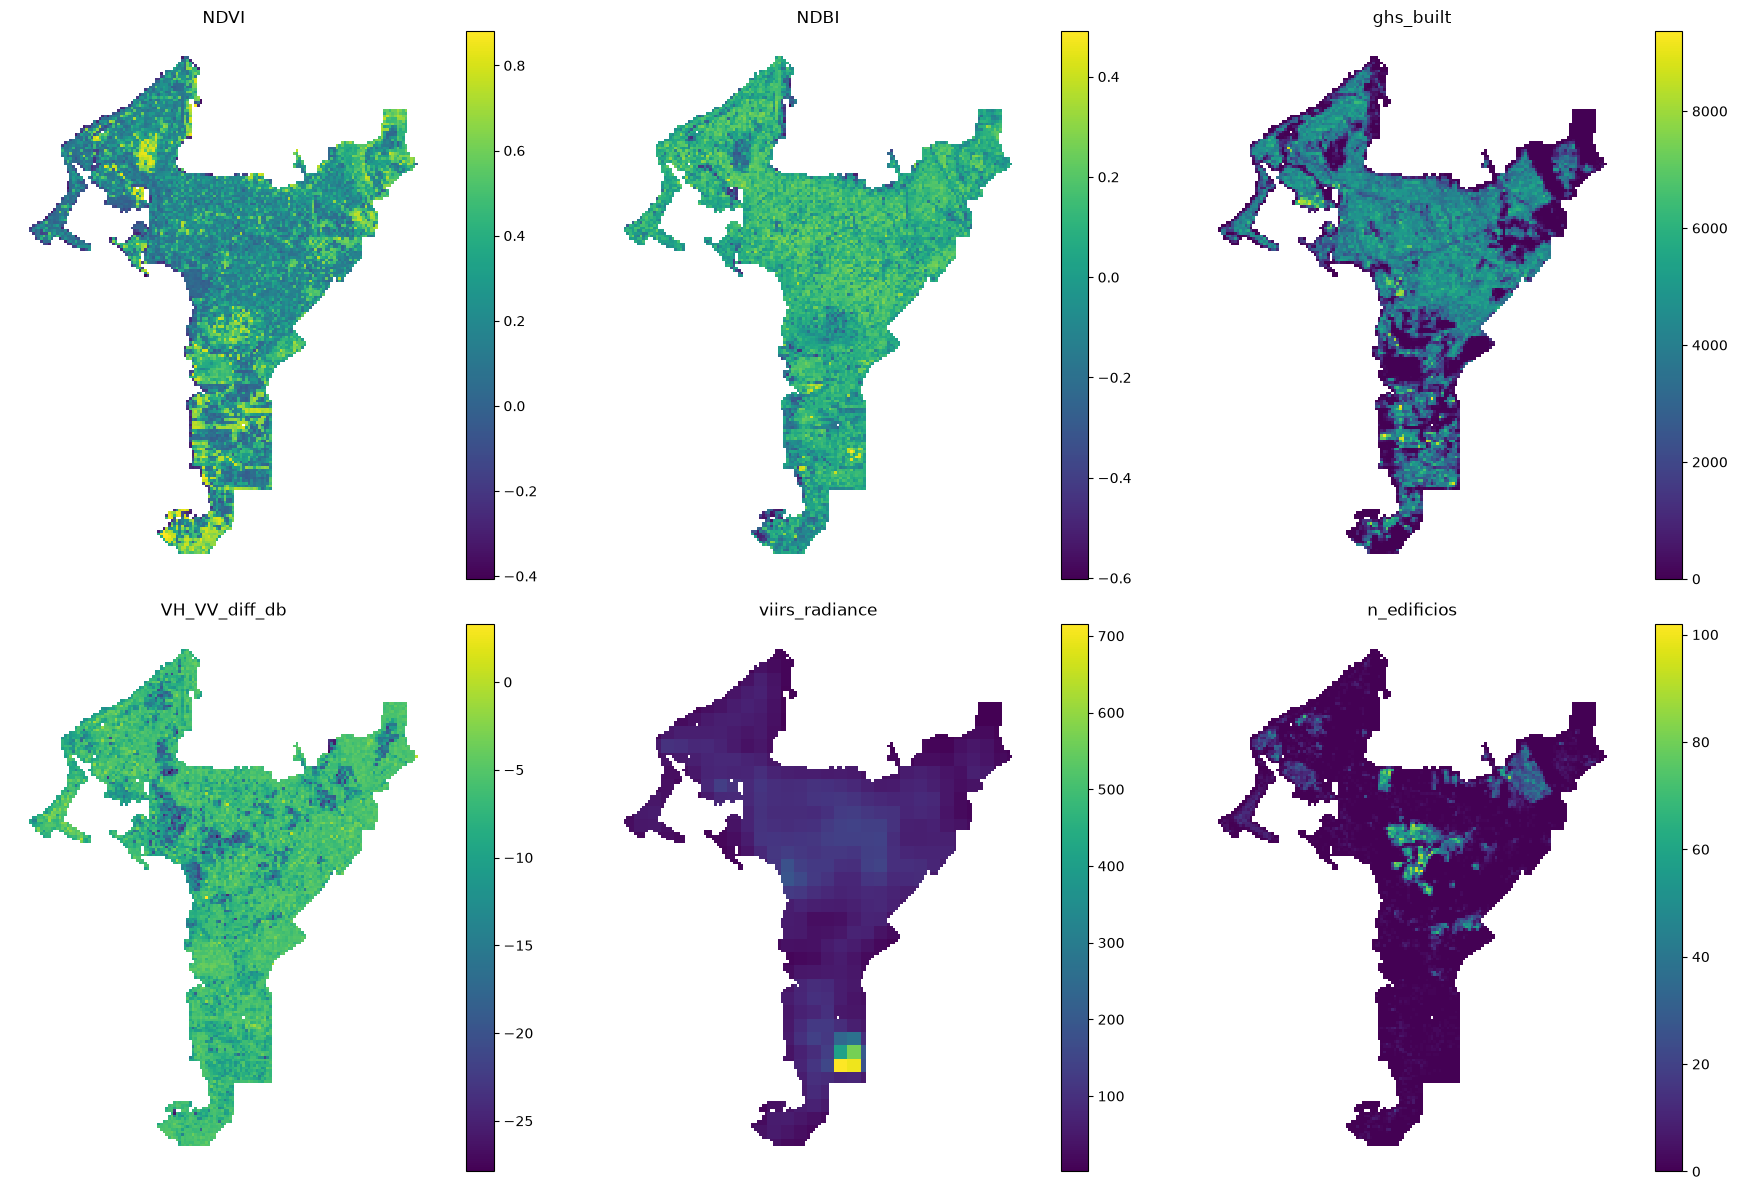

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
variables = ["NDVI", "NDBI", "ghs_built", "VH_VV_diff_db", "viirs_radiance", "n_edificios"]
for ax, var in zip(axes.flat, variables):
    grilla.plot(column=var, ax=ax, cmap="viridis", legend=True, markersize=0.5)
    ax.set_title(var)
    ax.set_axis_off()
plt.tight_layout()
plt.savefig(DATA_PROC / "fig_features_overview.png", dpi=120)
plt.show()

---
## Feature engineering completado

Siguiente paso: `03_modeling.py` — entrenar el Random Forest, validar y generar
el mapa de probabilidad sobre toda Cartagena.